## DeepCSAT – Ecommerce Customer Satisfaction Score Prediction

### Project Objectives   
##### Customer satisfaction e-commerce sector pivotal that influences loyalty, repeat business, and word-of-mouth marketing Traditionally, companies have relied on direct surveys to gouge customer satisfaction, which can be time-consuming and may not always capture the full spectrum of customer experiences. With the advent of deep learning, it's now possible to predict customer satisfaction scores in real offening a granular view of service performance and identifying areas for immediate improvement.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
data=pd.read_csv("eCommerce_Customer_support_data.csv")
data.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  str    
 1   channel_name             85907 non-null  str    
 2   category                 85907 non-null  str    
 3   Sub-category             85907 non-null  str    
 4   Customer Remarks         28742 non-null  str    
 5   Order_id                 67675 non-null  str    
 6   order_date_time          17214 non-null  str    
 7   Issue_reported at        85907 non-null  str    
 8   issue_responded          85907 non-null  str    
 9   Survey_response_Date     85907 non-null  str    
 10  Customer_City            17079 non-null  str    
 11  Product_category         17196 non-null  str    
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name               85907 no

In [4]:
data.columns=data.columns.str.lower().str.replace(" ","_").str.replace({"_":"","-":""})
data.columns

Index(['uniqueid', 'channelname', 'category', 'subcategory', 'customerremarks',
       'orderid', 'orderdatetime', 'issuereportedat', 'issueresponded',
       'surveyresponsedate', 'customercity', 'productcategory', 'itemprice',
       'connectedhandlingtime', 'agentname', 'supervisor', 'manager',
       'tenurebucket', 'agentshift', 'csatscore'],
      dtype='str')

In [5]:
data.issuereportedat=data.issuereportedat.astype("datetime64[ns]")
data.issueresponded=data.issueresponded.astype("datetime64[ns]")
data.surveyresponsedate=data.surveyresponsedate.astype("datetime64[ns]")

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   uniqueid               85907 non-null  str           
 1   channelname            85907 non-null  str           
 2   category               85907 non-null  str           
 3   subcategory            85907 non-null  str           
 4   customerremarks        28742 non-null  str           
 5   orderid                67675 non-null  str           
 6   orderdatetime          17214 non-null  str           
 7   issuereportedat        85907 non-null  datetime64[ns]
 8   issueresponded         85907 non-null  datetime64[ns]
 9   surveyresponsedate     85907 non-null  datetime64[ns]
 10  customercity           17079 non-null  str           
 11  productcategory        17196 non-null  str           
 12  itemprice              17206 non-null  float64       
 13  connectedhan

In [7]:
0.4*data.shape[0]

34362.8

In [8]:
isna=data.isna().sum()
isna

uniqueid                     0
channelname                  0
category                     0
subcategory                  0
customerremarks          57165
orderid                  18232
orderdatetime            68693
issuereportedat              0
issueresponded               0
surveyresponsedate           0
customercity             68828
productcategory          68711
itemprice                68701
connectedhandlingtime    85665
agentname                    0
supervisor                   0
manager                      0
tenurebucket                 0
agentshift                   0
csatscore                    0
dtype: int64

In [9]:
# data.drop(["customerremarks","orderdatetime","productcategory"],axis=1,inplace=True)        

In [10]:
y=data.csatscore

<Axes: xlabel='channelname', ylabel='count'>

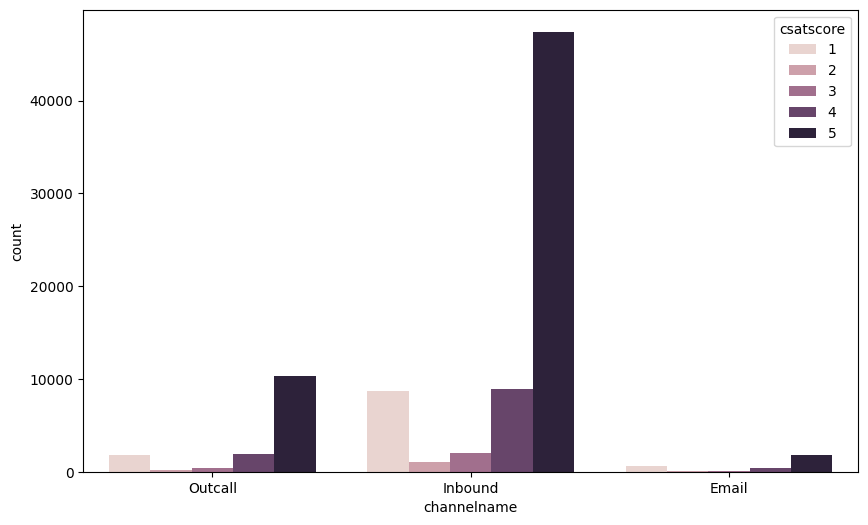

In [11]:
plt.figure(figsize=(10,6))
sns.countplot(x=data.channelname,hue=y)

In [12]:
data.groupby("channelname").csatscore.value_counts(normalize=True)

channelname  csatscore
Email        5            0.606351
             1            0.210387
             4            0.128349
             3            0.033741
             2            0.021171
Inbound      5            0.695885
             4            0.131109
             1            0.128335
             3            0.029835
             2            0.014837
Outcall      5            0.703093
             4            0.128680
             1            0.125424
             3            0.028694
             2            0.014109
Name: proportion, dtype: float64

#### Report:
- The Inbound channel (calls initiated by the customers) is most preffered by customers to interact with the shopzilla E-commerce site.
- **70.31%** of Outcall channelnamehave got **5 CSAT** score.
- These insights help businesses to focus more on outgoing channelname for interacting with their customers inorder to improve satisfaction of customer on the shopzilla site.

In [13]:
pd.crosstab(data.category,y,margins=True,normalize=True)

csatscore,1,2,3,4,5,All
category,,,,,,
App/website,0.000128,0.000000,0.000000,0.000070,0.000780,0.000978
Cancellation,0.005064,0.000466,0.000675,0.002992,0.016553,0.025749
Feedback,0.004086,0.000407,0.000885,0.003131,0.018194,0.026703
Offers & Cashback,0.000803,0.000023,0.000128,0.000873,0.003760,0.005587
Onboarding related,0.000105,0.000012,0.000023,0.000058,0.000559,0.000757
Order Related,0.043419,0.004912,0.009615,0.036633,0.175655,0.270234
Others,0.000338,0.000047,0.000081,0.000151,0.000535,0.001152
Payments related,0.002770,0.000407,0.000803,0.003574,0.019533,0.027087
Product Queries,0.006786,0.001059,0.002084,0.006775,0.026273,0.042977


Text(0.5, 1.0, 'Category Count')

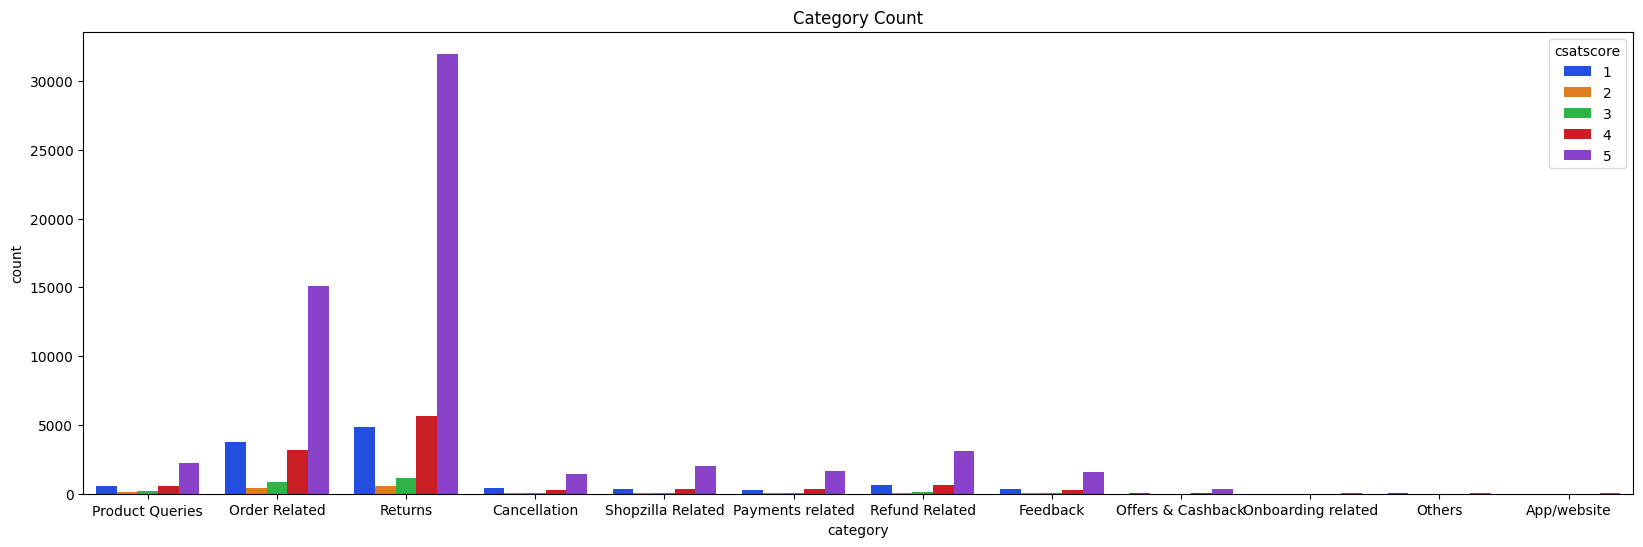

In [14]:
plt.figure(figsize=(20,6))
sns.countplot(x=data.category,hue=y,palette="bright")
plt.title("Category Count")

### Report 
- **Order Related** and **Returns** accounts for **78.13%** of category(issues) from the customers.
- Out of which **54.7%** of the customers have given **5** CSAT score.
- Bussiness should focus more on dealing with these categories(issues) to improve their CST score.

In [15]:
pd.crosstab([data.category, data.subcategory], y, margins=True,normalize=True)

csatscore                                                   1         2  \
category           subcategory                                            
App/website        App/website Related               0.000012  0.000000   
                   Issues with Shopzilla App         0.000116  0.000000   
Cancellation       Not Needed                        0.004808  0.000349   
                   Return cancellation               0.000256  0.000116   
Feedback           UnProfessional Behaviour          0.004086  0.000407   
Offers & Cashback  Affiliate Offers                  0.000396  0.000023   
                   Instant discount                  0.000047  0.000000   
                   Other Cashback                    0.000361  0.000000   
Onboarding related Commission related                0.000023  0.000000   
                   Seller onboarding                 0.000081  0.000012   
Order Related      Customer Requested Modifications  0.000664  0.000105   
                   Delayed                           0.015552  0.001490   
                   General Enquiry                   0.000501  0.000081   
                   Installation/demo                 0.009580  0.001280   
                   Invoice request                   0.001176  0.000244   
                   Order Verification                0.000105  0.000035   
                   Order status enquiry              0.011152  0.001292   
                   Priority delivery                 0.000896  0.000151   
                   Seller Cancelled Order            0.003550  0.000198   
                   Unable to track                   0.000244  0.000035   
Others             Call back request                 0.000128  0.000012   
                   Call disconnected                 0.000163  0.000035   
                   Non Order related                 0.000000  0.000000   
                   Others                            0.000047  0.000000   
Payments related   Billing Related                   0.000023  0.000023   
                   Card/EMI                          0.000058  0.000012   
                   Online Payment Issues             0.001129  0.000151   
                   PayLater related                  0.000163  0.000012   
                   Payment pending                   0.000012  0.000000   
                   Payment related Queries           0.000978  0.000151   
                   Wallet related                    0.000338  0.000023   
                   e-Gift Voucher                    0.000070  0.000035   
Product Queries    Life Insurance                    0.000023  0.000000   
                   Policy Related                    0.000000  0.000000   
                   Product Specific Information      0.006542  0.001048   
                   Warranty related                  0.000221  0.000012   
Refund Related     COD Refund Details                0.000186  0.000035   
                   Refund Enquiry                    0.003655  0.000442   
                   Refund Related Issues             0.003352  0.000279   
Returns            Damaged                           0.000442  0.000000   
                   Exchange / Replacement            0.001711  0.000175   
                   Fraudulent User                   0.002782  0.000268   
                   General Enquiry                   0.000035  0.000000   
                   Missing                           0.001618  0.000256   
                   Product related Issues            0.000151  0.000035   
                   Return request                    0.004656  0.000780   
                   Reverse Pickup Enquiry            0.037133  0.004202   
                   Self-Help                         0.000058  0.000035   
                   Service Center - Service Denial   0.000244  0.000023   
                   Service Centres Related           0.003655  0.000303   
                   Technician Visit                  0.001443  0.000035   
                   Wrong 

### Report 
- **Order Related** and **Returns** accounts for around **77%** of sub-category(issues) from the customers.
- Out of which around **53%** of the customers have given **5** CSAT score.
- Bussiness should focus more on dealing with these sub-categories(issues) to improve their CST score.

In [16]:
data.groupby("category")[["subcategory","csatscore"]].nunique()

,subcategory,csatscore
category,,
App/website,2,3
Cancellation,2,5
Feedback,1,5
Offers & Cashback,3,5
Onboarding related,2,5
Order Related,10,5
Others,4,5
Payments related,8,5
Product Queries,4,5


In [17]:
data.customerremarks.dropna()

7                                                Very good
8        Shopzilla app and it's all coustomer care serv...
11                                                Very bad
17                                              Something 
19                                                All good
                               ...                        
85887    If the customer care guy and their supervisors...
85888                          Good my problem was solved 
85896    Trough the Shopzilla App Refunding Policy shou...
85903             Supported team customer executive   good
85904                 need to improve with proper details.
Name: customerremarks, Length: 28742, dtype: str

In [18]:
data.issuereportedat.min(),data.issuereportedat.max()

(Timestamp('2023-01-08 00:00:00'), Timestamp('2023-12-08 23:59:00'))

In [19]:
data.issuereportedat.dt.month.value_counts(normalize=True)

issuereportedat
8     0.660156
7     0.038099
10    0.034735
11    0.033397
12    0.033303
9     0.032524
4     0.029590
6     0.029532
3     0.028577
2     0.027553
5     0.026482
1     0.026051
Name: proportion, dtype: float64

In [20]:
data.issueresponded.min(),data.issueresponded.max()

(Timestamp('2023-01-08 00:00:00'), Timestamp('2023-12-08 23:59:00'))

In [21]:
data.issueresponded.dt.month.value_counts(normalize=True)

issueresponded
8     0.663764
7     0.035084
10    0.034793
11    0.033688
12    0.033071
9     0.032861
4     0.029369
6     0.028985
3     0.028717
2     0.027122
5     0.026575
1     0.025970
Name: proportion, dtype: float64

### Report 
- Majority(**66.01%**) of issues reported are in month of **Augast**.
- Majority(**66.37%**) of issues responded are in month of **Augast**.
- This shows **Augast** is the peak month for issues and bussiness should efficiently tackle customers issues. 
- The issues are reported between *8-1-2023 -8-12-2023*.

In [22]:
a=(data.issueresponded-data.issuereportedat)
a

0       0 days 00:34:00
1       0 days 00:02:00
2       0 days 00:22:00
3       0 days 00:20:00
4       0 days 00:02:00
              ...      
85902   0 days 08:02:00
85903   0 days 00:02:00
85904   0 days 00:05:00
85905   0 days 00:01:00
85906   0 days 00:01:00
Length: 85907, dtype: timedelta64[ns]

In [23]:
a.dt.total_seconds()/3600

0        0.566667
1        0.033333
2        0.366667
3        0.333333
4        0.033333
           ...   
85902    8.033333
85903    0.033333
85904    0.083333
85905    0.016667
85906    0.016667
Length: 85907, dtype: float64

In [24]:
data["responsehours"]=a.dt.total_seconds()/3600
data.head(2)

,uniqueid,channelname,category,subcategory,customerremarks,orderid,orderdatetime,issuereportedat,issueresponded,surveyresponsedate,...,productcategory,itemprice,connectedhandlingtime,agentname,supervisor,manager,tenurebucket,agentshift,csatscore,responsehours
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,2023-01-08 11:13:00,2023-01-08 11:47:00,2023-08-01,...,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,0.566667
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,2023-01-08 12:52:00,2023-01-08 12:54:00,2023-08-01,...,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,0.033333


In [25]:
data.responsehours.max(),data.responsehours.min()

(np.float64(2951.616666666667), np.float64(-4919.966666666666))

In [26]:
data=data[data["responsehours"]>0].reset_index(drop=True)
data.shape

(79738, 21)

In [27]:
data.head(2)

,uniqueid,channelname,category,subcategory,customerremarks,orderid,orderdatetime,issuereportedat,issueresponded,surveyresponsedate,...,productcategory,itemprice,connectedhandlingtime,agentname,supervisor,manager,tenurebucket,agentshift,csatscore,responsehours
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,2023-01-08 11:13:00,2023-01-08 11:47:00,2023-08-01,...,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,0.566667
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,2023-01-08 12:52:00,2023-01-08 12:54:00,2023-08-01,...,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,0.033333


In [28]:
data.responsehours.max(),data.responsehours.min()

(np.float64(2951.616666666667), np.float64(0.016666666666666666))

In [29]:
data["responsehourscategory"]=pd.cut(data.responsehours,bins=[0,6,12,18,24,3000],labels=["within 6","6-12","12-18","18-24","24+"])

<Axes: xlabel='responsehourscategory', ylabel='count'>

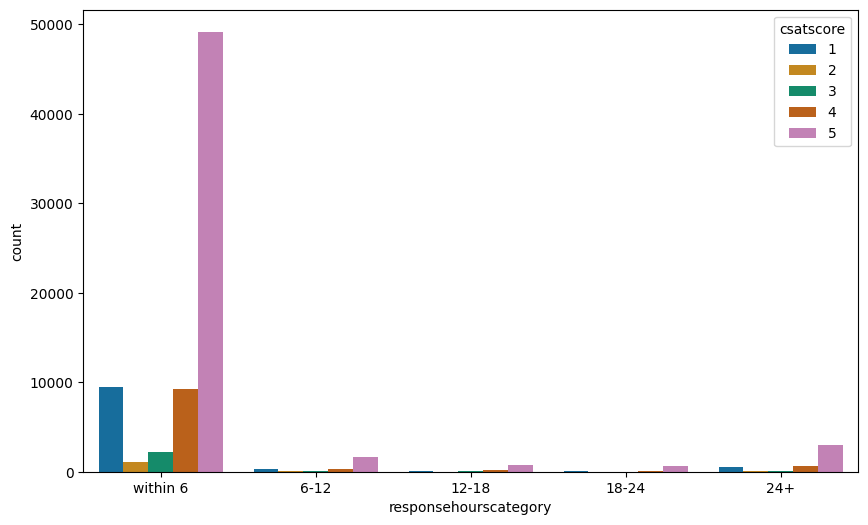

In [30]:
plt.figure(figsize=(10,6))
sns.countplot(x=data.responsehourscategory,hue=y,palette="colorblind")

In [31]:
pd.crosstab(data.responsehourscategory,y,margins=True,normalize=True)

csatscore,1,2,3,4,5,All
responsehourscategory,,,,,,
within 6,0.118363,0.013607,0.027064,0.115466,0.616594,0.891093
6-12,0.003562,0.000414,0.000790,0.004189,0.020730,0.029685
12-18,0.001580,0.000176,0.000464,0.001919,0.009757,0.013896
18-24,0.001292,0.000176,0.000301,0.001430,0.007412,0.010610
24+,0.007299,0.000765,0.001492,0.007625,0.037535,0.054717
All,0.132095,0.015137,0.030111,0.130628,0.692029,1.000000


### Report 
- Majority **(89.12%)** of the customers issues(categories) where responded **within 6 hours** which shows quick response time from shopzilla for the customers.
- Out of this Majority **63.11%** have given **5 CSAT** score.
- Other observation from the plot above is that for all the response time majority of the customers have given **5 CSAT** score , which shows their satisfaction level from the bussiness.

In [32]:
survey_reprted_difference=data.surveyresponsedate-data.issuereportedat
survey_reprted_difference

0       204 days 12:47:00
1       204 days 11:08:00
2       204 days 03:44:00
3       204 days 03:04:00
4       204 days 13:30:00
               ...       
79733     0 days 00:40:00
79734   -1 days +15:45:00
79735   -1 days +05:03:00
79736   -1 days +04:01:00
79737   -1 days +00:24:00
Length: 79738, dtype: timedelta64[ns]

In [33]:
24*3600

86400

In [34]:
diff=survey_reprted_difference.dt.total_seconds()/86400
diff,diff.shape

(0        204.532639
 1        204.463889
 2        204.155556
 3        204.127778
 4        204.562500
             ...    
 79733      0.027778
 79734     -0.343750
 79735     -0.789583
 79736     -0.832639
 79737     -0.983333
 Length: 79738, dtype: float64,
 (79738,))

In [35]:
data.issueresponded.min(),data.issueresponded.max()

(Timestamp('2023-01-08 00:01:00'), Timestamp('2023-12-08 23:59:00'))

In [36]:
data.surveyresponsedate.min(),data.surveyresponsedate.max()

(Timestamp('2023-08-01 00:00:00'), Timestamp('2023-08-31 00:00:00'))

### Report
- The Surveys are taken in the month of **Augast** where majority of issues were reported and responded.
- Top 10 survey response dates accounts for **37.21%** of total survey response taken.

In [37]:
data.customercity.value_counts(ascending=False)

customercity
HYDERABAD       657
NEW DELHI       636
PUNE            409
MUMBAI          368
BANGALORE       328
               ... 
NAWALGARH         1
MUKUNDAPURAM      1
VALPOI            1
DORAHA            1
KODUR             1
Name: count, Length: 1733, dtype: int64

In [38]:
data.customercity.isna().sum()

np.int64(63908)

In [39]:
top10custcity=data.customercity.value_counts(ascending=False).head(10)
top10custcity

customercity
HYDERABAD    657
NEW DELHI    636
PUNE         409
MUMBAI       368
BANGALORE    328
KOLKATA      253
CHENNAI      246
LUCKNOW      238
AHMEDABAD    233
JAIPUR       222
Name: count, dtype: int64

In [40]:
top10custcitydf=data[data.customercity.isin(top10custcity.index)]
top10custcitydf.shape

(3590, 22)

<Axes: xlabel='customercity', ylabel='count'>

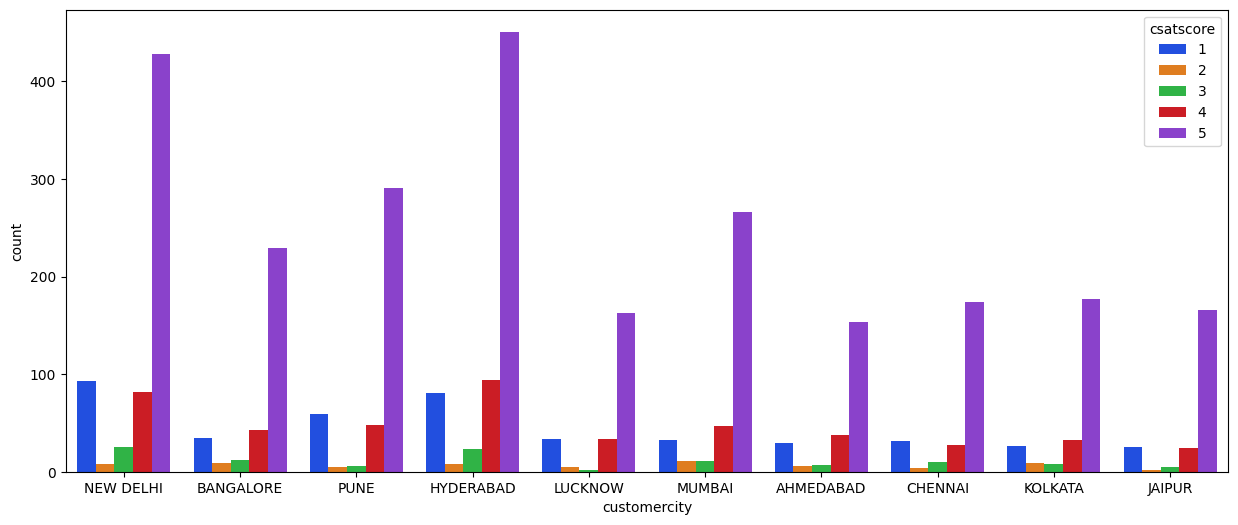

In [41]:
plt.figure(figsize=(15,6))
sns.countplot(x=top10custcitydf.customercity,hue=y,palette="bright")

### Report
- **Hyderabad** and **New Delhi** customers have the majority of interaction with the shopzilla.
- Majority of the customers from the top10 cities have given **5 CSAT** score which shows shopzilla excellent customer service which affects the CSAT score.

In [42]:
data.productcategory.value_counts(ascending=False)

productcategory
Electronics                    4377
LifeStyle                      3816
Books & General merchandise    3067
Mobile                         1628
Home Appliences                1224
Home                           1213
Furniture                       429
Affiliates                      156
GiftCard                         24
Name: count, dtype: int64

In [43]:
pd.crosstab(data.productcategory,data.category,margins=True)

category,Cancellation,Feedback,Offers & Cashback,Order Related,Others,Payments related,Product Queries,Refund Related,Returns,Shopzilla Related,All
productcategory,,,,,,,,,,,
Affiliates,2,5,0,37,0,0,0,9,102,1,156
Books & General merchandise,171,138,6,1261,7,6,2,181,1291,4,3067
Electronics,165,89,5,1283,5,8,3,197,2619,3,4377
Furniture,36,25,1,194,0,1,2,20,150,0,429
GiftCard,0,2,6,9,1,1,0,3,2,0,24
Home,54,56,3,495,2,2,1,89,509,2,1213
Home Appliences,44,42,9,558,1,5,6,91,466,2,1224
LifeStyle,136,112,3,1049,9,10,0,328,2169,0,3816
Mobile,146,34,23,872,0,13,2,157,375,6,1628


### Report 
- **Electronics** and **Books & General Merchandise** are the majority of the product category for which the customer interact for their issues.
- The Bussiness should focus more on delivering quality product for these categories so as to reduce the issues raised by the customers.

In [44]:
data.itemprice.describe()

count     15944.000000
mean       5667.504014
std       12874.881838
min           0.000000
25%         394.000000
50%         990.000000
75%        2699.000000
max      164999.000000
Name: itemprice, dtype: float64

In [45]:
data.itemprice.skew()

np.float64(4.261279388158547)

In [46]:
data.itemprice.value_counts(ascending=False).head(18)

itemprice
999.0      551
1499.0     303
899.0      293
1299.0     281
799.0      264
1099.0     199
499.0      177
1199.0     177
299.0      172
32999.0    162
1999.0     153
1599.0     148
1399.0     144
1699.0     142
399.0      141
599.0      126
699.0      123
29999.0    114
Name: count, dtype: int64

### Report 
- Price range from **299 - 32999** accounts for the majority of the items for iteraction between the customers and shopzilla.

In [47]:
pd.crosstab(data.tenurebucket,y,margins=True)

csatscore,1,2,3,4,5,All
tenurebucket,,,,,,
0-30,1401,160,322,1393,7314,10590
31-60,1498,166,345,1440,7524,10973
61-90,870,101,181,820,4365,6337
>90,3740,404,861,3627,19985,28617
On Job Training,3024,376,692,3136,15993,23221
All,10533,1207,2401,10416,55181,79738


<Axes: xlabel='tenurebucket', ylabel='count'>

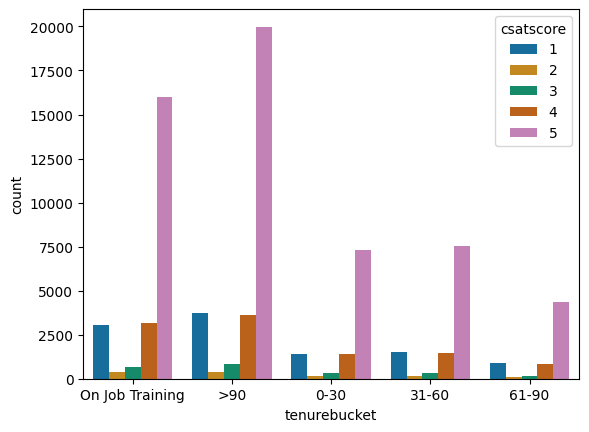

In [48]:
sns.countplot(x=data.tenurebucket,hue=y,palette="colorblind")

### Reports 
- The **On job training and >90 days** agents handle the majority of intreactions made by customers.
- These interaction sessions with the customers were give majorly **5 CSAT** score which proves their skills and efficiency for dealing with the customers.
- This could be a positive sign of growth as the new Agents are trained well and are delivering the results in the most beneficial way for the bussiness.

In [49]:
data.agentshift.value_counts(ascending=False)

agentshift
Morning      38446
Evening      31205
Afternoon     5416
Split         3433
Night         1238
Name: count, dtype: int64

Text(0.5, 1.0, 'Agents shift with the CSAT score and count')

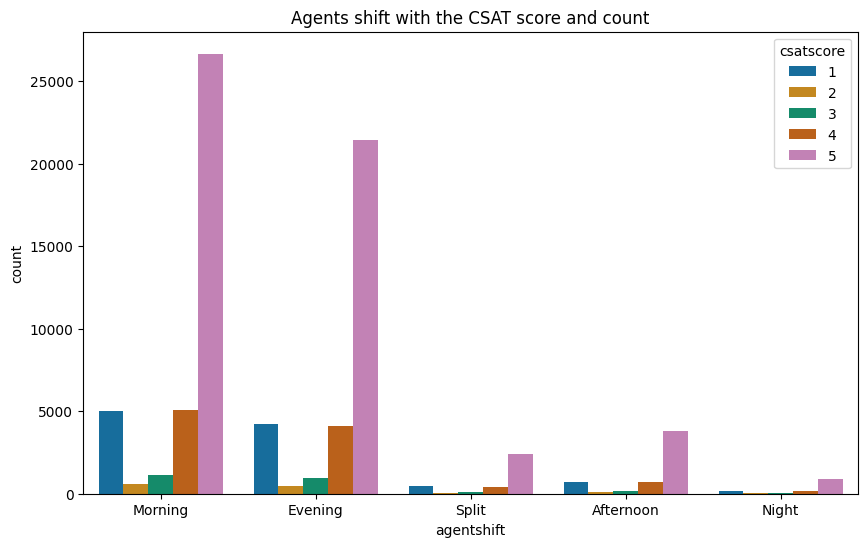

In [50]:
plt.figure(figsize=(10,6))
sns.countplot(x=data.agentshift,hue=y,palette="colorblind")
plt.title("Agents shift with the CSAT score and count")

### Report 
- Majority of the agents work in either the **morning** or the **evening** shift.
- Majority of the customers have **5 CSAT** Score for all the agent shifts.
- This shows a positive sign for the growth of Bussiness, the Agents are highly skilled in effeciently handling the customers interactions with the shopzilla business.

In [51]:
data.columns

Index(['uniqueid', 'channelname', 'category', 'subcategory', 'customerremarks',
       'orderid', 'orderdatetime', 'issuereportedat', 'issueresponded',
       'surveyresponsedate', 'customercity', 'productcategory', 'itemprice',
       'connectedhandlingtime', 'agentname', 'supervisor', 'manager',
       'tenurebucket', 'agentshift', 'csatscore', 'responsehours',
       'responsehourscategory'],
      dtype='str')

In [52]:
pd.crosstab(data.agentname,data.csatscore,margins=True)

csatscore,1,2,3,4,5,All
agentname,,,,,,
Aaron Edwards,9,0,3,9,64,85
Aaron Romero,12,1,2,6,30,51
Abigail Gonzalez,5,0,0,3,14,22
Adam Barnett,6,0,2,9,33,50
Adam Hammond,1,0,2,8,46,57
...,...,...,...,...,...,...
Zachary Collins,22,0,1,16,29,68
Zachary Ford,13,1,2,10,30,56
Zachary Reyes,6,0,3,9,33,51


In [53]:
data.groupby("agentname")["csatscore"].value_counts().sort_values(ascending=False).head(25)

agentname            csatscore
Wendy Taylor         5            280
Timothy Huff         5            199
David Smith          5            197
Kayla Wilson         5            147
Anthony Booth        5            146
Jamie Smith          5            145
Sharon Bullock       5            140
Julie Williams       5            137
Brianna Wolf         5            137
Jennifer Hernandez   5            136
Matthew White PhD    5            132
Tina Harrington      5            130
Ryan Thompson        5            128
Mrs. Jennifer Stone  5            128
Robert Lewis         5            127
Kathryn Jones        5            126
Brian Young          5            123
Dr. Heather Lewis    5            122
William Carey DVM    5            122
Brandon Frost        5            121
Darren Watson        5            121
Tracy Weaver         5            118
Kristin Campbell     5            115
Cole Moore           5            111
Amy Berry            5            111
Name: count, dtype:

### Report
- The top agents have recieved **5 CSAT** score by the customers.

In [54]:
data.supervisor.nunique()

40

In [55]:
data.groupby("supervisor")["csatscore"].value_counts().sort_values(ascending=False).head(10)

supervisor        csatscore
Carter Park       5            2707
Elijah Yamaguchi  5            2680
Nathan Patel      5            2369
Noah Patel        5            2333
Mia Patel         5            2135
Zoe Yamamoto      5            2103
Ava Wong          5            2066
Emma Park         5            1984
Evelyn Kimura     5            1928
Aiden Patel       5            1900
Name: count, dtype: int64

### Report
- The number of agents per supervisor ranges from **5-70** Agents.
- The **Top 7** Supervisors have **2000+ 5 CSAT** score given by the customers showing their skilled team of strong agents.
- Thsi shows the quality of Supervisors to handle customer interaction for the bussiness is high. 

In [56]:
data.manager.value_counts()

manager
John Smith         23632
Michael Lee        16453
Jennifer Nguyen    14469
Emily Chen         13243
William Kim         7794
Olivia Tan          4147
Name: count, dtype: int64

<Axes: xlabel='manager', ylabel='count'>

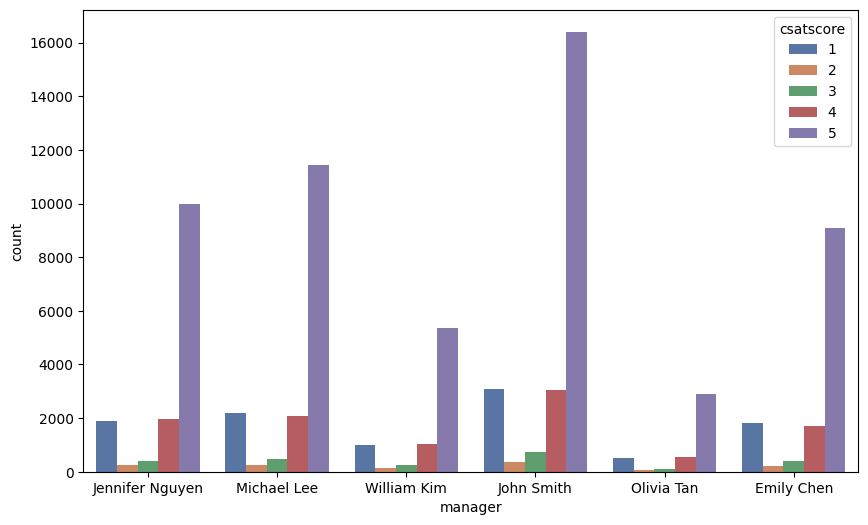

In [57]:
plt.figure(figsize=(10,6))
sns.countplot(x=data.manager,hue=y,palette="deep")

### Reports 
- **John Smith** is the **Best** Manager of the shopzilla for handling customer interactions.
- **All** the Managers are givens **Majority** of **5 CSAT** score by the customers.
- This plot shows highly skilled quality team the shopzilla bussiness have which will help in faster growth of the company.

In [58]:
data.customerremarks=data.customerremarks.fillna("")

In [59]:
data.isna().sum()

uniqueid                     0
channelname                  0
category                     0
subcategory                  0
customerremarks              0
orderid                  17560
orderdatetime            63786
issuereportedat              0
issueresponded               0
surveyresponsedate           0
customercity             63908
productcategory          63804
itemprice                63794
connectedhandlingtime    79501
agentname                    0
supervisor                   0
manager                      0
tenurebucket                 0
agentshift                   0
csatscore                    0
responsehours                0
responsehourscategory        0
dtype: int64

##### Here i am making my final data my dropping the features who have than 40% nan values as they wont have any statitical significance and imputing them will lead to learn those imputed adta rather than the actual data.

In [60]:
df=data.drop(["orderdatetime","customercity","productcategory","orderid","uniqueid","itemprice","connectedhandlingtime","responsehours","responsehourscategory"],axis=1)
df.shape

(79738, 13)

In [61]:
df.to_csv("final_data.csv",index=False)